# 03 — Frequency Domain Filtering & Restoration
## Smart City Surveillance System — CS 406 Digital Image Processing CCP

**Requires:** `01_preprocessing.ipynb` must be run first — this notebook loads the processed dataset directly from Google Drive.

Covers: 2D FFT & magnitude spectrum visualization, ideal/Butterworth/Gaussian low-pass and high-pass filtering in the frequency domain, and image restoration (motion blur simulation, inverse filtering, Wiener filtering).

## Step 1 — Mount Google Drive and set paths

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'
PROCESSED_DIR = Path(f'{PROJECT_DIR}/data/processed')

assert PROCESSED_DIR.exists(), 'Run 01_preprocessing.ipynb first — processed data not found in Drive.'
print('Data found. Ready to proceed.')

Mounted at /content/drive
Data found. Ready to proceed.


## Step 2 — Imports and metrics

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.fft import fft2, fftshift, ifft2, ifftshift
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def compute_psnr(original, processed):
    return psnr(original, processed, data_range=255)

def compute_ssim(original, processed):
    return ssim(original, processed, channel_axis=-1 if original.ndim == 3 else None, data_range=255)

## Step 3 — Load a test image (grayscale, for frequency-domain work)

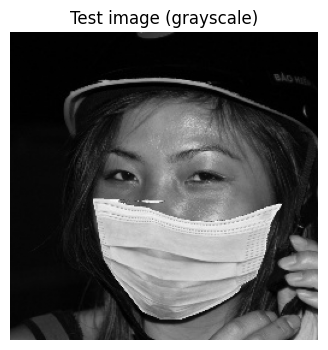

In [ ]:
test_img_path = list((PROCESSED_DIR / "with_mask").glob("*.jpg"))[0]
test_img_color = cv2.imread(str(test_img_path))
test_img_gray = cv2.cvtColor(test_img_color, cv2.COLOR_BGR2GRAY).astype(np.float64)

plt.figure(figsize=(4,4))
plt.imshow(test_img_gray, cmap="gray")
plt.title("Test image (grayscale)")
plt.axis("off")
plt.show()

## Step 4 — 2D FFT and magnitude spectrum visualization
This is required for your report's Methodology section — shows you understand what the frequency domain representation actually looks like.

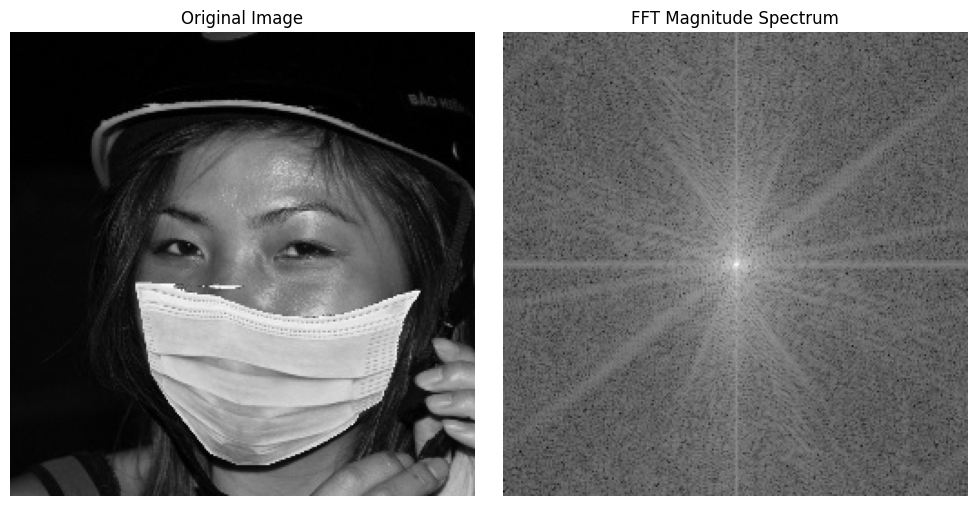

In [ ]:
F = fft2(test_img_gray)
F_shifted = fftshift(F)
magnitude_spectrum = 20 * np.log(np.abs(F_shifted) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(test_img_gray, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(magnitude_spectrum, cmap="gray")
axes[1].set_title("FFT Magnitude Spectrum")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/fft_magnitude_spectrum.png', dpi=150)
plt.show()

## Step 5 — Frequency-domain filters: Ideal, Butterworth, Gaussian
Each implemented for both low-pass (smoothing/denoising) and high-pass (edge/detail enhancement) variants.

In [ ]:
def create_distance_matrix(shape):
    rows, cols = shape
    crow, ccol = rows // 2, cols // 2
    y, x = np.ogrid[:rows, :cols]
    distance = np.sqrt((y - crow)**2 + (x - ccol)**2)
    return distance

def ideal_filter(shape, cutoff, highpass=False):
    distance = create_distance_matrix(shape)
    mask = (distance <= cutoff).astype(np.float64)
    return 1 - mask if highpass else mask

def butterworth_filter(shape, cutoff, order=2, highpass=False):
    distance = create_distance_matrix(shape)
    distance[distance == 0] = 1e-6  # avoid division by zero at center
    mask = 1 / (1 + (distance / cutoff)**(2 * order))
    return 1 - mask if highpass else mask

def gaussian_filter_freq(shape, cutoff, highpass=False):
    distance = create_distance_matrix(shape)
    mask = np.exp(-(distance**2) / (2 * (cutoff**2)))
    return 1 - mask if highpass else mask

def apply_freq_filter(img_gray, filter_mask):
    F = fft2(img_gray)
    F_shifted = fftshift(F)
    F_filtered = F_shifted * filter_mask
    img_back = np.abs(ifft2(ifftshift(F_filtered)))
    return np.clip(img_back, 0, 255).astype(np.uint8)

## Step 6 — Apply and compare all 6 filter variants

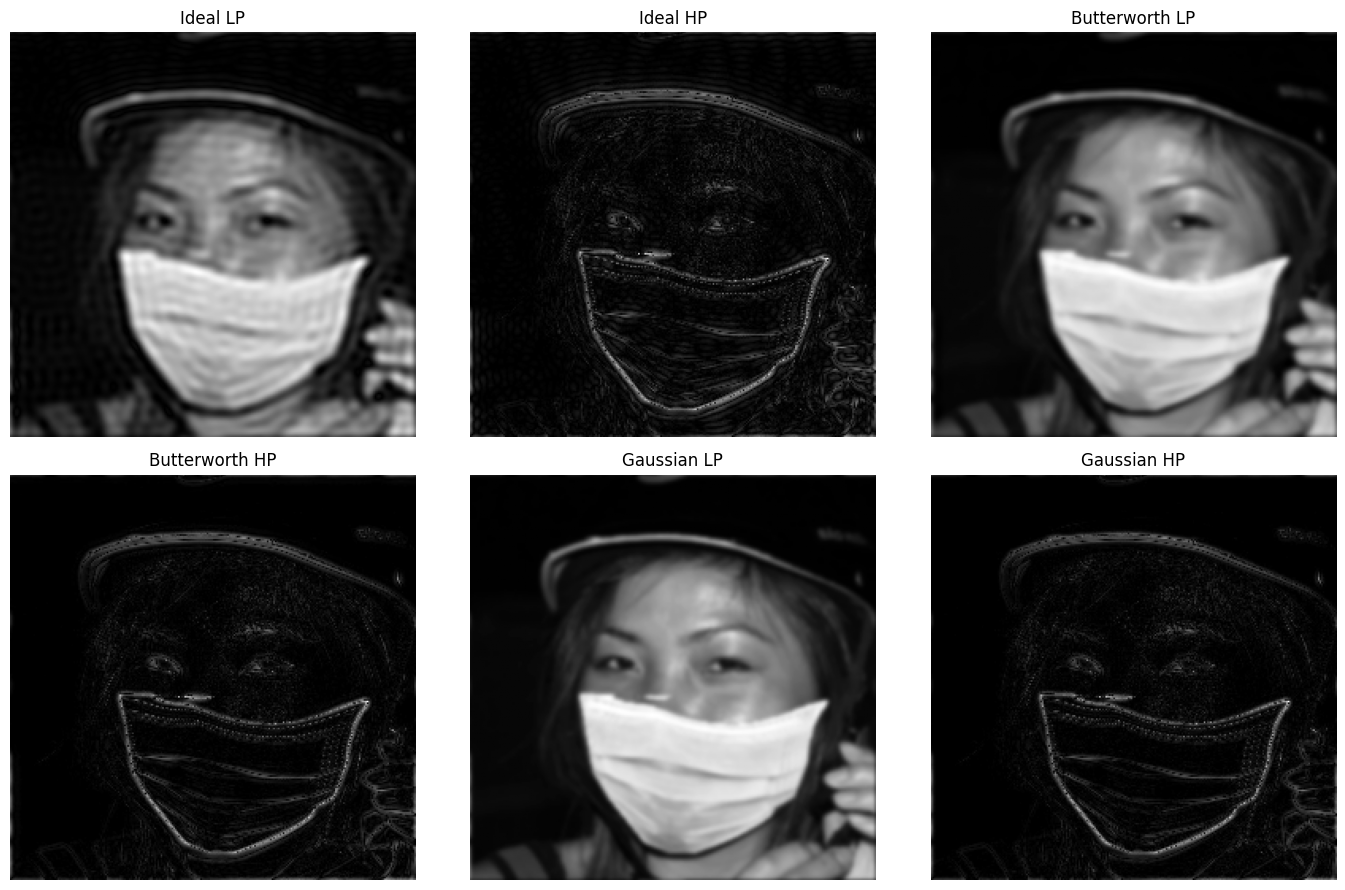

In [ ]:
CUTOFF = 30
shape = test_img_gray.shape

filters = {
    "Ideal LP": ideal_filter(shape, CUTOFF, highpass=False),
    "Ideal HP": ideal_filter(shape, CUTOFF, highpass=True),
    "Butterworth LP": butterworth_filter(shape, CUTOFF, highpass=False),
    "Butterworth HP": butterworth_filter(shape, CUTOFF, highpass=True),
    "Gaussian LP": gaussian_filter_freq(shape, CUTOFF, highpass=False),
    "Gaussian HP": gaussian_filter_freq(shape, CUTOFF, highpass=True),
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (name, mask) in zip(axes.flat, filters.items()):
    result = apply_freq_filter(test_img_gray, mask)
    ax.imshow(result, cmap="gray")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/frequency_filters_comparison.png', dpi=150)
plt.show()

**Note for your report:** low-pass filters smooth/blur (useful for denoising in poor lighting or sensor noise conditions), while high-pass filters sharpen edges (useful for enhancing vehicle/pedestrian boundaries). Ideal filters cause visible ringing artifacts (Gibbs phenomenon) due to the sharp cutoff — Butterworth and Gaussian give smoother, more natural transitions. This trade-off directly relates to the brief's 'Noise Removal vs. Detail Preservation' requirement.

## Step 7 — Image Restoration: simulate blur degradation

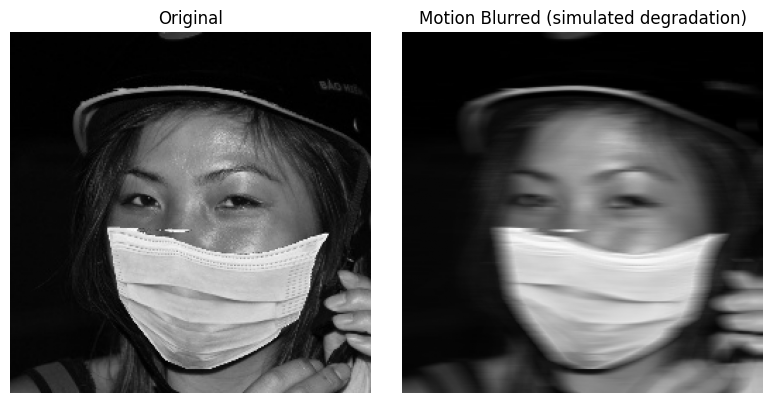

In [ ]:
def motion_blur_kernel(size=15, angle=0):
    kernel = np.zeros((size, size))
    kernel[(size - 1) // 2, :] = np.ones(size)
    kernel = kernel / size
    return kernel

kernel = motion_blur_kernel(size=15)
blurred_img = cv2.filter2D(test_img_gray, -1, kernel)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(test_img_gray, cmap="gray")
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(blurred_img, cmap="gray")
plt.title("Motion Blurred (simulated degradation)")
plt.axis("off")
plt.tight_layout()
plt.show()

## Step 8 — Restoration via Inverse Filtering

In [ ]:
def inverse_filter(blurred_img, kernel, shape):
    kernel_padded = np.zeros(shape)
    kh, kw = kernel.shape
    kernel_padded[:kh, :kw] = kernel
    kernel_padded = np.roll(kernel_padded, -kh//2, axis=0)
    kernel_padded = np.roll(kernel_padded, -kw//2, axis=1)

    H = fft2(kernel_padded)
    G = fft2(blurred_img)

    epsilon = 1e-3  # avoids division by near-zero frequencies (a known instability of inverse filtering)
    H_inv = np.where(np.abs(H) > epsilon, 1 / H, 0)
    F_hat = G * H_inv
    restored = np.abs(ifft2(F_hat))
    return np.clip(restored, 0, 255).astype(np.uint8)

restored_inverse = inverse_filter(blurred_img, kernel, test_img_gray.shape)

print(f"PSNR (blurred vs original): {compute_psnr(test_img_gray.astype(np.uint8), blurred_img.astype(np.uint8)):.2f}")
print(f"PSNR (inverse-restored vs original): {compute_psnr(test_img_gray.astype(np.uint8), restored_inverse):.2f}")

PSNR (blurred vs original): 24.44
PSNR (inverse-restored vs original): 8.50


## Step 9 — Restoration via Wiener Filtering
Wiener filtering handles noise amplification much better than plain inverse filtering, since it accounts for the noise-to-signal power ratio instead of blindly inverting.

In [ ]:
def wiener_filter(blurred_img, kernel, shape, K=0.01):
    kernel_padded = np.zeros(shape)
    kh, kw = kernel.shape
    kernel_padded[:kh, :kw] = kernel
    kernel_padded = np.roll(kernel_padded, -kh//2, axis=0)
    kernel_padded = np.roll(kernel_padded, -kw//2, axis=1)

    H = fft2(kernel_padded)
    G = fft2(blurred_img)

    H_conj = np.conj(H)
    wiener_H = H_conj / (np.abs(H)**2 + K)
    F_hat = G * wiener_H
    restored = np.abs(ifft2(F_hat))
    return np.clip(restored, 0, 255).astype(np.uint8)

restored_wiener = wiener_filter(blurred_img, kernel, test_img_gray.shape, K=0.01)

print(f"PSNR (Wiener-restored vs original): {compute_psnr(test_img_gray.astype(np.uint8), restored_wiener):.2f}")
print(f"SSIM (Wiener-restored vs original): {compute_ssim(test_img_gray.astype(np.uint8), restored_wiener):.4f}")

PSNR (Wiener-restored vs original): 20.77
SSIM (Wiener-restored vs original): 0.6328


## Step 10 — Compare all restoration results side by side

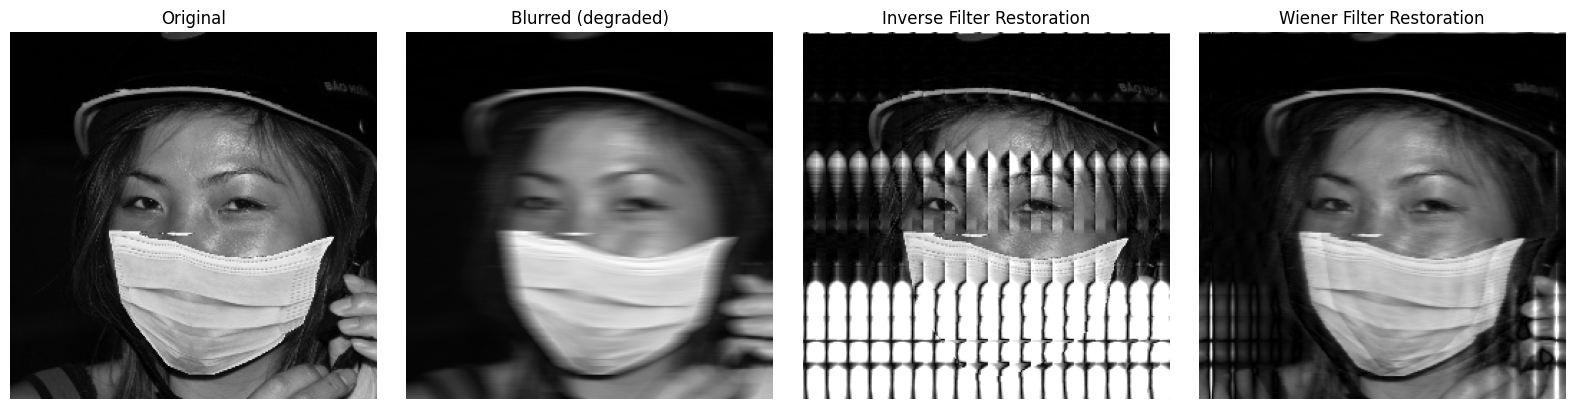

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ['Original', 'Blurred (degraded)', 'Inverse Filter Restoration', 'Wiener Filter Restoration']
images = [test_img_gray.astype(np.uint8), blurred_img.astype(np.uint8), restored_inverse, restored_wiener]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/figures/restoration_comparison.png', dpi=150)
plt.show()

## Step 11 — Full evaluation across the dataset
Runs the blur → inverse-restore → Wiener-restore pipeline over a sample of images per class, logging PSNR/SSIM at each stage.

In [ ]:
import random
random.seed(42)

results = []
class_names = ["with_mask", "without_mask", "incorrect_mask"]
SAMPLE_SIZE = 30

for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), SAMPLE_SIZE)

    for f in files:
        img = cv2.imread(str(f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)

        blurred = cv2.filter2D(gray, -1, kernel)
        inv_restored = inverse_filter(blurred, kernel, gray.shape)
        wiener_restored = wiener_filter(blurred, kernel, gray.shape, K=0.01)

        gray_u8 = gray.astype(np.uint8)
        blurred_u8 = blurred.astype(np.uint8)

        results.append({
            "class": class_name, "stage": "blurred",
            "psnr": compute_psnr(gray_u8, blurred_u8), "ssim": compute_ssim(gray_u8, blurred_u8)
        })
        results.append({
            "class": class_name, "stage": "inverse_filter",
            "psnr": compute_psnr(gray_u8, inv_restored), "ssim": compute_ssim(gray_u8, inv_restored)
        })
        results.append({
            "class": class_name, "stage": "wiener_filter",
            "psnr": compute_psnr(gray_u8, wiener_restored), "ssim": compute_ssim(gray_u8, wiener_restored)
        })

df = pd.DataFrame(results)
df.to_csv(f'{PROJECT_DIR}/results/tables/frequency_restoration_results.csv', index=False)
summary = df.groupby(["stage"])[["psnr", "ssim"]].mean().round(3)
summary.to_csv(f'{PROJECT_DIR}/results/tables/frequency_restoration_summary.csv')
print(summary)

                  psnr   ssim
stage                        
blurred         26.272  0.759
inverse_filter   8.779  0.137
wiener_filter   22.008  0.660


---
**Phase 4 complete.** Results saved to Drive:
- `results/figures/fft_magnitude_spectrum.png`
- `results/figures/frequency_filters_comparison.png`
- `results/figures/restoration_comparison.png`
- `results/tables/frequency_restoration_summary.csv` — paste into your report's Results section

**Expected finding for your Discussion:** Wiener filtering should show higher PSNR/SSIM than plain inverse filtering, since inverse filtering is unstable at frequencies where H is small (amplifies noise), while Wiener's K parameter regularizes against exactly that problem.

**Next: `04_segmentation.ipynb`** — edge-based (Sobel, Canny) and region-based (region growing, watershed) segmentation, evaluated with IoU and Dice coefficient.

         psnr   ssim
K                   
0.001  19.224  0.521
0.010  22.098  0.664
0.100  21.728  0.716
1.000  11.218  0.528


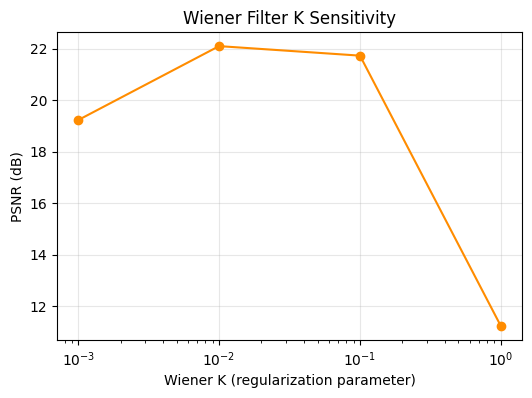

In [ ]:
# ===== Wiener K Sensitivity Study =====
k_results = []
K_values = [0.001, 0.01, 0.1, 1.0]

random.seed(42)
for class_name in class_names:
    class_dir = PROCESSED_DIR / class_name
    files = random.sample(list(class_dir.glob("*.jpg")), 20)

    for f in files:
        img = cv2.imread(str(f))
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float64)
        blurred = cv2.filter2D(gray, -1, kernel)
        gray_u8 = gray.astype(np.uint8)

        for K in K_values:
            restored = wiener_filter(blurred, kernel, gray.shape, K=K)
            k_results.append({
                "class": class_name, "K": K,
                "psnr": compute_psnr(gray_u8, restored),
                "ssim": compute_ssim(gray_u8, restored)
            })

k_df = pd.DataFrame(k_results)
k_df.to_csv(f'{PROJECT_DIR}/results/tables/wiener_k_sensitivity_results.csv', index=False)
k_summary = k_df.groupby("K")[["psnr", "ssim"]].mean().round(3)
k_summary.to_csv(f'{PROJECT_DIR}/results/tables/wiener_k_sensitivity_summary.csv')
print(k_summary)

plt.figure(figsize=(6,4))
plt.semilogx(k_summary.index, k_summary['psnr'], 'o-', color='darkorange')
plt.xlabel("Wiener K (regularization parameter)")
plt.ylabel("PSNR (dB)")
plt.title("Wiener Filter K Sensitivity")
plt.grid(alpha=0.3)
plt.savefig(f'{PROJECT_DIR}/results/figures/wiener_k_sensitivity.png', dpi=150)
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
PROJECT_DIR = '/content/drive/MyDrive/smart-city-surveillance-dip'

# Per-class spatial filtering breakdown
spatial_df = pd.read_csv(f'{PROJECT_DIR}/results/tables/spatial_filtering_results.csv')
spatial_per_class = spatial_df[spatial_df['filter']=='median'].groupby('class')[['psnr','ssim']].mean().round(3)
print("=== Spatial Filtering (Median) Per-Class ===")
print(spatial_per_class)

# Per-class restoration breakdown
restoration_df = pd.read_csv(f'{PROJECT_DIR}/results/tables/frequency_restoration_results.csv')
restoration_per_class = restoration_df[restoration_df['stage']=='wiener_filter'].groupby('class')[['psnr','ssim']].mean().round(3)
print("\n=== Restoration (Wiener) Per-Class ===")
print(restoration_per_class)

# Per-class segmentation breakdown (using the filled Canny results)
seg_df = pd.read_csv(f'{PROJECT_DIR}/results/tables/segmentation_results_v2.csv')
seg_per_class = seg_df[seg_df['method']=='canny_filled'].groupby('class')[['iou','dice']].mean().round(3)
print("\n=== Segmentation (Canny Filled) Per-Class ===")
print(seg_per_class)

Mounted at /content/drive
=== Spatial Filtering (Median) Per-Class ===
                  psnr   ssim
class                        
incorrect_mask  26.091  0.723
with_mask       28.692  0.766
without_mask    33.171  0.845

=== Restoration (Wiener) Per-Class ===
                  psnr   ssim
class                        
incorrect_mask  21.092  0.594
with_mask       21.360  0.620
without_mask    23.571  0.766

=== Segmentation (Canny Filled) Per-Class ===
                  iou   dice
class                       
incorrect_mask  0.478  0.635
with_mask       0.414  0.561
without_mask    0.260  0.357
